**Loading, Preparing and Splitting Data**

In [1]:
!pip install opencv-python

In [2]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
from glob import glob
from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from skimage import exposure
import pickle
import cv2
import random
import sys

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
base_dir = '/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Δεδομένα - Εικόνες(σε μορφή jpg)/Εικόνες jpg'

In [13]:
sys.path.append('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή')
from PreProcessing_Script import dataset_preparation

In [5]:
df = pd.DataFrame({'path': glob(os.path.join(base_dir, '*', '*.jpg'))})

In [6]:
df['file_id'] = df['path'].map(lambda x: os.path.splitext(os.path.basename(x))[0])
df['cell_type'] = df['path'].map(lambda x: os.path.basename(os.path.dirname(x)))
df['cell_type_idx'] = df['cell_type'].map(lambda x: int(x.split('_')[0]))

In [7]:
label_map = {
    1: "glioma",
    2: "meningioma",
    3: "pituitary"
}
df['cell_type'] = df['cell_type_idx'].map(label_map)

In [ ]:
df.shape

(3064, 5)

In [ ]:
df.head(10)

,path,file_id,cell_type,cell_type_idx,label
0,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1,glioma,1,1
1,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,10,glioma,1,1
2,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,100,glioma,1,1
3,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,101,glioma,1,1
4,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,102,glioma,1,1
5,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,103,glioma,1,1
6,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,104,glioma,1,1
7,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,105,glioma,1,1
8,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,106,glioma,1,1
9,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,107,glioma,1,1


In [8]:
IMG_SIZE = 224

In [9]:
df['image'] = df['path'].map(lambda x: cv2.resize(cv2.imread(x, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)))

In [10]:
df.to_pickle('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Δεδομένα - Εικόνες(σε μορφή jpg)/Εικόνες jpg.pkl')

In [11]:
df=pd.read_pickle('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Δεδομένα - Εικόνες(σε μορφή jpg)/Εικόνες jpg.pkl')

In [12]:
df

,path,file_id,cell_type,cell_type_idx,image
0,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1,glioma,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,10,glioma,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,100,glioma,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,101,glioma,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,102,glioma,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...
3059,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,995,pituitary,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3060,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,996,pituitary,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3061,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,997,pituitary,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3062,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,998,pituitary,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
df.isnull().sum()

,0
path,0
file_id,0
cell_type,0
cell_type_idx,0
label,0
image,0


In [ ]:
df.dtypes

,0
path,object
file_id,object
cell_type,object
cell_type_idx,int64
label,int64
image,object


In [ ]:
df['cell_type'].value_counts()

,count
cell_type,
meningioma,1426
pituitary,930
glioma,708


In [14]:
df[['path', 'file_id', 'cell_type', 'cell_type_idx']].head(5)

,path,file_id,cell_type,cell_type_idx
0,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1,glioma,1
1,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,10,glioma,1
2,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,100,glioma,1
3,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,101,glioma,1
4,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,102,glioma,1


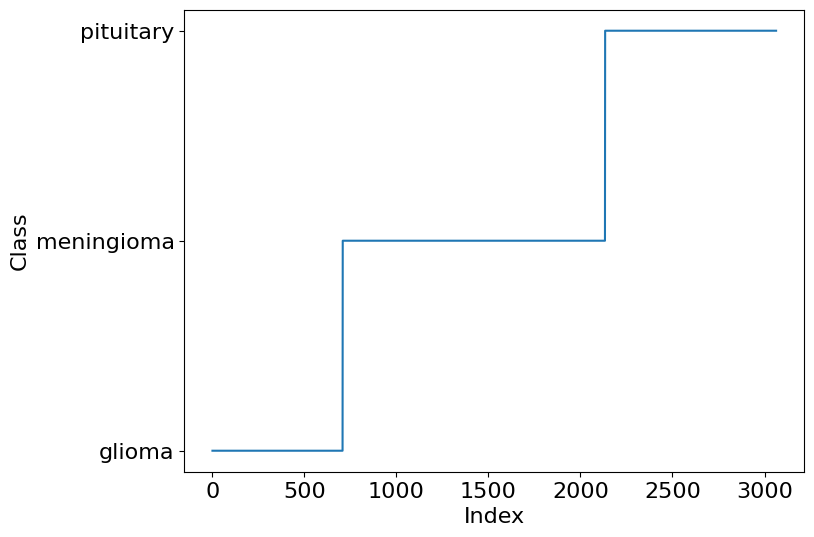

In [ ]:
fig = plt.figure(figsize=(8,6))
plt.plot(df.index.values, df['cell_type'])
plt.xlabel('Index', fontsize = 16)
plt.ylabel('Class', fontsize = 16)
plt.tick_params(labelsize=16)
plt.show()

In [15]:
rows = df.index.values
random.shuffle(rows)
rows

array([1588, 2443,  804, ...,  853, 1225, 2840])

In [16]:
df=df.reindex(rows)
df.sort_index(inplace=True)

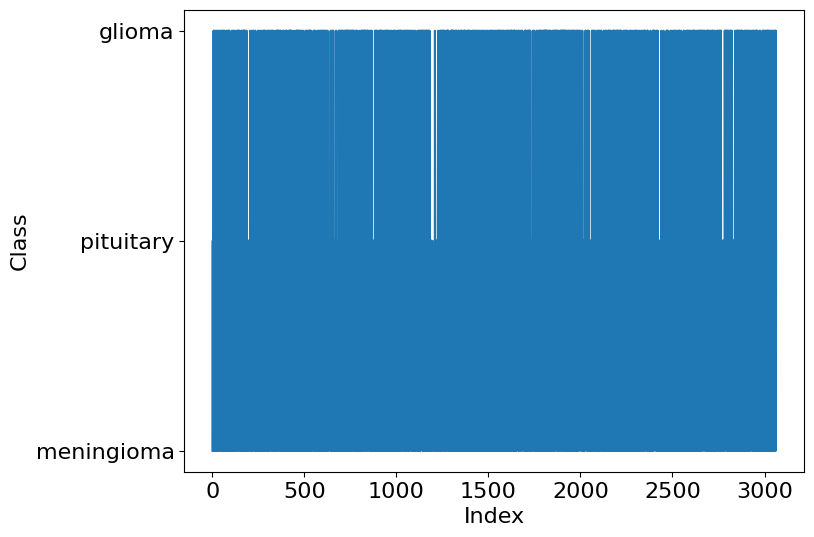

In [ ]:
fig = plt.figure(figsize=(8,6))
plt.plot(df.index.values, df['cell_type'])
plt.xlabel('Index', fontsize = 16)
plt.ylabel('Class', fontsize = 16)
plt.tick_params(labelsize=16)
plt.show()

In [ ]:
df.head(10)

,path,file_id,cell_type,cell_type_idx,label,image,full_image_name
0,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1190,pituitary,3,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1190
1,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,2577,meningioma,2,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2577
2,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1343,pituitary,3,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1343
3,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,144,glioma,1,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",144
4,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1372,pituitary,3,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1372
5,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,204,glioma,1,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",204
6,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,2729,meningioma,2,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2729
7,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,2654,meningioma,2,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2654
8,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,2283,meningioma,2,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2283
9,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1368,pituitary,3,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1368


In [17]:
df_label = pd.get_dummies(df['cell_type'])
df.head()

,path,file_id,cell_type,cell_type_idx,image
0,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,2554,meningioma,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1222,pituitary,3,"[[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,..."
2,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,2807,meningioma,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1439,pituitary,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προ...,1784,pituitary,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [18]:
label=df_label.values
label

array([[False,  True, False],
       [False, False,  True],
       [False,  True, False],
       ...,
       [False, False,  True],
       [ True, False, False],
       [False,  True, False]])

In [19]:
y_int = np.argmax(label, axis=1)

In [20]:
dict_label=list(df_label.columns)
dict_label

['glioma', 'meningioma', 'pituitary']

In [21]:
data=np.array(df['image'].tolist())
data

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 2, 2, 2],
        [0, 0, 0, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 5, 5, 2],
        [0, 0, 0, ..., 4, 5, 3],
        [0, 0, 0, ..., 1, 2, 2]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 2, 2, 2],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 3, 3, 3],
        [1, 1, 1, ..., 2, 2, 2],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

**Preprocessing**

In [22]:
x_train_val, x_test, y_train_val_int, y_test_int = train_test_split(
    data, y_int,
    test_size = 0.2,
    random_state = 42,
    stratify=y_int
)

x_train_val_raw = x_train_val.copy()
x_test_raw = x_test.copy()

In [23]:
print('1- Training Set: ', x_train_val_raw.shape, y_train_val_int.shape)
print('3- Testing Set: ', x_test_raw.shape, y_test_int.shape)

1- Training Set:  (2451, 224, 224) (2451,)
3- Testing Set:  (613, 224, 224) (613,)


In [24]:
print("dtype:", x_train_val_raw.dtype)
print("shape:", x_train_val_raw.shape)
print("min value:", x_train_val_raw.min())
print("max value:", x_train_val_raw.max())

dtype: uint8
shape: (2451, 224, 224)
min value: 0
max value: 255


In [25]:
print("channels:", x_train_val_raw.shape[-1] if x_train_val_raw.ndim == 4 else 1)

channels: 1


In [26]:
print(x_train_val_raw.dtype)
print(x_train_val_raw.min(), x_train_val_raw.max())

uint8
0 255


In [27]:
os.makedirs('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data', exist_ok=True)

In [28]:
with open('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/x_train_val_raw.pkl', 'wb') as f: pickle.dump(x_train_val_raw, f, protocol=pickle.HIGHEST_PROTOCOL)
with open('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/x_test_raw.pkl', 'wb') as f: pickle.dump(x_test_raw, f, protocol=pickle.HIGHEST_PROTOCOL)

In [29]:
with open('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/y_train_val_int.pkl', 'wb') as f: pickle.dump(y_train_val_int, f, protocol=pickle.HIGHEST_PROTOCOL)
with open('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/y_test_int.pkl', 'wb') as f: pickle.dump(y_test_int, f, protocol=pickle.HIGHEST_PROTOCOL)